# From SQL to Insight: Practical Data Analysis in Pandas

This notebook demonstrates how SQL-style analytical queries can be translated into pandas workflows, applied to a realistic dataset to generate insights.

This type of analysis is commonly used in customer analytics, product performance tracking and financial reporting.

## Advantages of Pandas

- The functions can easily be stored for future use
   
- Can pass the output of one function in the input to another

- There is usually sigificantly less code 
   
- Functions can be made interactive 

-  Can (easily) run on command line and within analysis script for pipelines

- The complexity and size of the SQL standard means that most implementers do not support the entire standard – so may be some incomptability with peers

- Last and definitely not least, MySQL was wreaking havoc on my Mac without ever atually being used: Using over 90% of RAM at random times and hogging about 100 GB of storage. So, this is more of a reminder to myself, **stay clear of MySQL!!!**


See https://github.com/steviecurran/sql2csv to convert .sql to .csv, via the C shell

## Layout

We start with a simple business problem to illustrate common SQL equivalent tasks, followed by complex tasks which may be required for data manipulation.

###  Business Problem 1

We analyse a transactional dataset to answer key questions:

- Which customers generate the most revenue?
- How is revenue distributed across customers?
- Are there high-value segments worth targeting?

This mirrors common analytics tasks typically performed in SQL, implemented here in pandas.


### Data Manipulation

We then link to regular SQL functions for quick reference, accessible from the table below.

<a id='cont'></a>

**Function Contents**

|SELECT		| Aggregate              | ORDER and GROUP       | JOIN | Others| 
| :---     | :---    | :--- | :---   | :-- | 
|**[WHERE](#WHERE)**  |**[COUNT](#COUNT)**  |**[ORDER BY](#OB)**    |**[INNER](#INNER)**  |**[DISTINCT](#DIST)**| 
|**[OR](#OR)**  |**[SUM](#AGG)**         |**[GROUP COUNT](#GC)** |**[OUTER](#OUTER)** |**[FILTER](#FIL)**|
|**[AND and OR](#AO)** |**[MIN and MAX](#AGG)** |**[GROUP AGG](#GA)** |**[LEFT/RIGHT](#LR)**  |**[CASE](#CAS)**|  
| **[IN/NOT IN](#IN)** |**[AVG](#AGG)** |**[HAVING](#HA)**|**[MULTIPLE tables](#MUL)** |**[Window functions](#WF)** |
| **[LIKE/NOT LIKE](#LIKE)**      |**[MEDIAN](#AGG)**      |**[DUPLICATES](#DUP)** |**[JOIN WHERE](#JW)**       | |
| **[BETWEEN/NOT BETWEEN](#BET)** |        |       | **[CROSS JOIN](#CJ)**      | |
| **[IS NULL/NOT NULL](#NULL)**   |          |      | **[Aggregate and JOIN](#AJ)**||


### [Business Problem 2](#BP2)

Where we use the above functions to breakdown the salaries by department.

## Business Problem 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example dataset 
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    "customer_id": np.random.randint(1, 101, n),
    "transaction_value": np.random.exponential(100, n),
    "date": pd.date_range(start="2023-01-01", periods=n, freq="D")
})
df

,customer_id,transaction_value,date
0,52,88.392306,2023-01-01
1,93,136.821665,2023-01-02
2,15,56.503465,2023-01-03
3,72,13.648467,2023-01-04
4,61,33.376218,2023-01-05
...,...,...,...
995,10,174.908873,2025-09-22
996,67,152.338907,2025-09-23
997,18,123.355507,2025-09-24
998,100,3.683037,2025-09-25


###  Example 1: SELECT + WHERE

In [6]:
# SQL:
# SELECT * FROM df WHERE transaction_value > 150

filtered_df = df[df["transaction_value"] > 0]
filtered_df

,customer_id,transaction_value,date
0,52,88.392306,2023-01-01
1,93,136.821665,2023-01-02
2,15,56.503465,2023-01-03
3,72,13.648467,2023-01-04
4,61,33.376218,2023-01-05
...,...,...,...
995,10,174.908873,2025-09-22
996,67,152.338907,2025-09-23
997,18,123.355507,2025-09-24
998,100,3.683037,2025-09-25


### Example 2: GROUP BY

In [7]:
# SQL:
# SELECT customer_id, SUM(transaction_value)
# FROM df GROUP BY customer_id

customer_revenue = df.groupby("customer_id")["transaction_value"].sum().reset_index()
customer_revenue

,customer_id,transaction_value
0,1,950.565161
1,2,1836.233435
2,3,900.998443
3,4,1301.817830
4,5,1504.849172
...,...,...
95,96,1382.974738
96,97,873.938962
97,98,680.112760
98,99,1453.627259


### Example 3: ORDER BY

In [8]:
# SQL:
# ORDER BY transaction_value DESC

customer_revenue.sort_values(by="transaction_value", ascending=False)

,customer_id,transaction_value
44,45,2759.627878
62,63,2336.180268
91,92,2035.599894
1,2,1836.233435
68,69,1803.124075
...,...,...
39,40,374.950756
67,68,347.473326
30,31,249.079326
82,83,245.550336


### Query: Which customers generate the most revenue?

We analyse how revenue is distributed across customers.

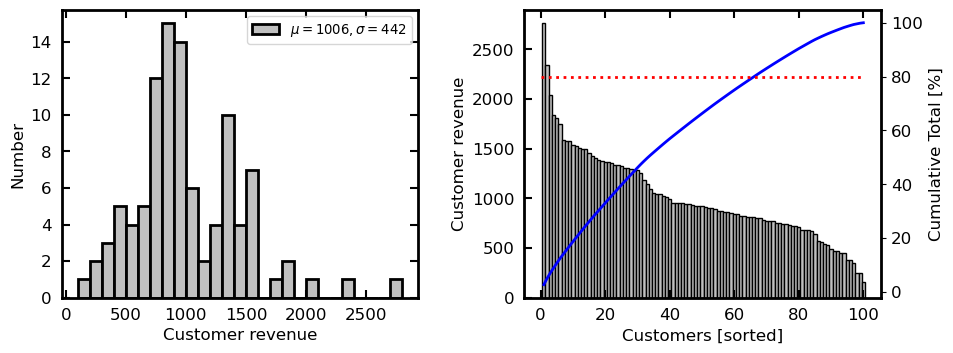

In [9]:
# DON'T REALLY NEED FUNCTION HERE, BUT THIS IS MORE READILY ADAPTABLE TO OTHER DATASETS
from IPython.display import Markdown, display
def hist_pareto(data,para,dbw,xlab):     
    min_val, max_val = data[para].min(), data[para].max()
    min_boundary = -1.0 * (min_val % dbw - min_val)
    max_boundary = max_val - max_val % dbw + dbw
    n_bins = int((max_boundary - min_boundary) / dbw) + 1
    bins = np.linspace(min_boundary, max_boundary, n_bins)
    
    font = 12
    plt.rcParams.update({'font.size': font})
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10, 4)) 
    
    def nice_axes(ax):
        plt.setp(ax.spines.values(),linewidth=2)
        ax.tick_params(direction='in', pad = 7,length=6, width=1.5, which='major',right=True,top=True)
        ax.tick_params(direction='in', pad = 7,length=3, width=1.5, which='minor',right=True,top=True)
    nice_axes(ax1); nice_axes(ax2)
    
    ## ----------- HISTOGRAM -----------#
    mean = np.mean(data[para]); std = np.std(data[para],ddof=1)
    label = "$\mu = %1.0f, \sigma = %1.0f$" %(mean, std)
    ax1.hist(data[para], bins=bins, color="silver", edgecolor='k', lw=2, label=label)      
    ax1.set_xlabel(xlab); ax1.set_ylabel('Number')
    ax1.legend(fontsize = 0.8*font,loc='best')
    ## ----------- PARETO -------------#
    total = data[para].sum()
    data = data.sort_values(by=[para],ascending=False).reset_index(drop=True)
    data['sum'] = data[para].cumsum()
    data['percent'] = 100*data['sum']/total
    eighty = data[data['percent'] <= 80]
    #print(data)
    ax2.bar(data.index +1, data[para],lw=1, width = 1, ec = "k", fc = 'silver')  
    ax2.set_ylabel(xlab)
    ax2.set_xlabel('Customers [sorted]')
    
    secax2 = ax2.twinx()
    secax2.plot(data.index + 1, data['percent'], color='b', lw=2)
    secax2.set_ylabel('Cumulative Total [%]')
    secax2.hlines(80, 0, data.index[-1] + 1, linestyle='dotted', color='r', lw=2)
    #----------------------------------#
    plt.tight_layout(pad=2)
    return eighty

#### dataset, parameter, desired bin width (dbw), xlabel
eighty = hist_pareto(customer_revenue,"transaction_value",100,'Customer revenue')

In [6]:
#print(eighty)
pc = 100*float(len(eighty))/len(customer_revenue)

if pc < 30:
    pmeas = 'strong'
elif (pc >= 30) and (pc < 60):
    pmeas = 'moderate'
elif (pc >= 60) and (pc < 70):
    pmeas = 'weak'
else:
    pmeas = 'zero'

print('************************************** Key Insight ***********************************')
print('80%% of revenue is generated by the top %1.1f%% customers, which is a %s Pareto effect' 
      %(pc, pmeas))
print('**************************************************************************************')

************************************** Key Insight ***********************************
80% of revenue is generated by the top 66.0% customers, which is a weak Pareto effect
**************************************************************************************


This suggests:
- strong potential for targeted retention strategies
- prioritisation of high-value customers

This level of concentration suggests that both targeted and broad-based strategies may be required, rather than focusing exclusively on a small subset of customers.

### Business Interpretation

- A small number of customers drive a large proportion of revenue  
- Targeted marketing or retention strategies could focus on these customers  
- This type of analysis is commonly performed in SQL, but pandas enables more flexible exploration and integration with Python workflows

### Time Series

Using the dates we can also show how the revenue varies over time.

   customer_id  transaction_value       date
0           52          88.392306 2023-01-01
1           93         136.821665 2023-01-02
2           15          56.503465 2023-01-03
3           72          13.648467 2023-01-04
4           61          33.376218 2023-01-05


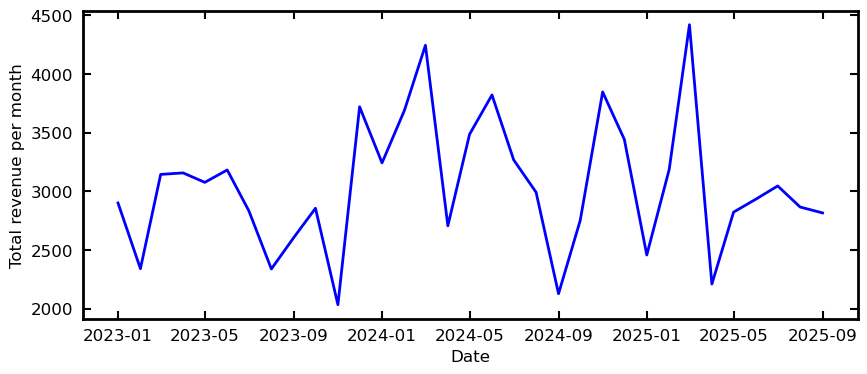

In [7]:
print(df.head())
def time_plot(data,date_col,para,freq,save):
    font = 12
    plt.rcParams.update({'font.size': font})
    plt.figure(figsize = (10,4))
    ax = plt.gca();
    plt.setp(ax.spines.values(), linewidth=2)
    ax.tick_params(direction='in', pad = 7,length=6, width=1.5, which='major',right=True,top=True)
    ax.tick_params(direction='in', pad = 7,length=3, width=1.5, which='minor',right=True,top=True)
    
    # Convert to datetime only if it isn't already
    temp_datetime = pd.to_datetime(data[date_col].astype(str)) 
    temp_periods = temp_datetime.dt.to_period(freq)
    gr = data.groupby(temp_periods)[para].sum()
    
    conv = {'D': 'day','W':'week','M':'month'}
    cfreq = conv.get(freq)

    x = gr.index.to_timestamp()
    y = gr.values
    
    plt.plot(x,y, c = 'b',ls = '-',lw=2)
    plt.xlabel('Date'); plt.ylabel('Total revenue per %s' %(cfreq))
    
    if save == True:
        out = '%s-%s.csv' %(para,cfreq)
        gr.to_csv(out)
        print('Data written to %s' %(out))
    
# freq = D for daily, W for weekly, M for monthly. Save = True to save data for forecasting
time_plot(df,'date','transaction_value','M',False)

**Note the options to resample the dates and the option to save the data in order to perform time series forcasting, which can be done with https://github.com/steviecurran/time-series-toolkit**

## Data Manipulation

We now show further more general examples of data manipulation which require working across several data sets

These emulate the SQL queries in the *Relational Database Theory & Introduction to SQL* chapter of Udemy's 
[The Business Intelligence Analyst Course]( https://www.udemy.com/course/the-business-intelligence-analyst-course-2018). I found SQL just to clunky, confusing and inefficent, so I wrote these

These can quickly be found via the links in the [Function Contents](#cont)

In [8]:
import glob,os
pd.options.mode.chained_assignment = None

Loading example data

In [9]:
# List the files in the currrent folder and import
csv = glob.glob('*.csv'); print(csv) 
emp = pd.read_csv("employees.csv");
sal = pd.read_csv("salaries.csv");
dep = pd.read_csv("departments.csv")
man = pd.read_csv("dept_manager.csv")
dept_emp = pd.read_csv("dept_emp.csv")
titles = pd.read_csv("titles.csv")

['salaries.csv', 'dept_emp.csv', 'dept_manager.csv', 'salaries_trun.csv', 'departments.csv', 'titles.csv', 'transaction_value-month.csv', 'employees.csv']


[Back to contents](#cont)

### SELECT 

**<a id='WHERE'>SELECT FROM</a>**

E.g. list anyone with the first name *Elvis* in the employee data set (*employees.csv*)

In [10]:
def SELECT(data,field,entry):
    return data[data[field] == entry]

In [11]:
SELECT(emp,'first_name',"Elvis") # E.g. select from employee table anyone with first name Elvis

,emp_no,birth_date,first_name,last_name,gender,hire_date
29,10030,1958-07-14,Elvis,Demeyer,M,1994-02-17
1049,11050,1952-09-23,Elvis,Katiyar,M,1986-05-06
2869,12870,1960-03-24,Elvis,Pfau,F,1990-04-09
3619,13620,1956-10-31,Elvis,Dolinsky,M,1985-06-12
4433,14434,1954-07-08,Elvis,Maginnis,M,1987-11-27
...,...,...,...,...,...,...
295430,495406,1956-05-04,Elvis,Gerlach,M,1990-09-17
296527,496503,1956-09-01,Elvis,Verhoeff,M,1986-10-27
297934,497910,1961-05-12,Elvis,Cannard,F,1990-09-23
298645,498621,1955-09-07,Elvis,Zykh,M,1993-08-31


 [Back to contents](#cont)
 
 **<a id='WHERE'>SELECT WHERE</a>**
 
 E.g. from the employee dataset, list anyone with first name *Denis* and gender M

In [12]:
def SELECT_WHERE(data,field1,entry1,field2,entry2): 
    return data[(data[field1] == entry1) & (data[field2] == entry2)]

In [13]:
SELECT_WHERE(emp,'first_name',"Denis",'gender',"M") 

,emp_no,birth_date,first_name,last_name,gender,hire_date
5082,15083,1958-11-24,Denis,Nicolson,M,1994-03-02
7223,17224,1955-04-06,Denis,Back,M,1985-07-29
8120,18121,1953-08-26,Denis,Stanfel,M,1990-05-21
8186,18187,1965-01-08,Denis,Falster,M,1989-10-12
9797,19798,1962-12-22,Denis,Schmezko,M,1986-10-30
...,...,...,...,...,...,...
290517,490493,1956-07-06,Denis,Auyong,M,1989-04-15
290863,490839,1958-06-19,Denis,Narwekar,M,1987-12-09
291119,491095,1962-05-30,Denis,Kuszyk,M,1992-12-05
296968,496944,1954-09-02,Denis,Fortenbacher,M,1986-02-09


In [14]:
SELECT_WHERE(emp,'first_name',"Elvis",'last_name',"Presley") # Sorry, just had to

,emp_no,birth_date,first_name,last_name,gender,hire_date


[Back to contents](#cont)

**WHERE with comparison operator**

E.g. from employee dataset, list employees hired after 2000-01-01 

In [15]:
def FILTER(data,field,entry,action):
    act = "print(data[data[field] %s entry])" %(action)
    exec(act)

In [16]:
FILTER(emp,'hire_date','2000-01-01','>') # after 2000-01-01 exclusive

        emp_no  birth_date first_name   last_name gender   hire_date
37290    47291  1960-09-09        Ulf      Flexer      M  2000-01-12
50133    60134  1964-04-21      Seshu    Rathonyi      F  2000-01-02
62328    72329  1953-02-09      Randi        Luit      F  2000-01-02
105072  205048  1960-09-12      Ennio      Alblas      F  2000-01-06
122989  222965  1959-08-07    Volkmar       Perko      F  2000-01-13
126657  226633  1958-06-10     Xuejun  Benzmuller      F  2000-01-04
127568  227544  1954-11-17     Shahab     Demeyer      M  2000-01-08
223014  422990  1953-04-09      Jaana    Verspoor      F  2000-01-11
224469  424445  1953-04-27      Jeong     Boreale      M  2000-01-03
228401  428377  1957-05-09      Yucai     Gerlach      M  2000-01-23
263831  463807  1964-06-12     Bikash      Covnot      M  2000-01-28
299577  499553  1954-05-06   Hideyuki   Delgrande      F  2000-01-22


In [17]:
FILTER(emp,'hire_date','2000-01-01','>=') # after 2000-01-01 inclusive

        emp_no  birth_date   first_name   last_name gender   hire_date
37290    47291  1960-09-09          Ulf      Flexer      M  2000-01-12
50133    60134  1964-04-21        Seshu    Rathonyi      F  2000-01-02
62328    72329  1953-02-09        Randi        Luit      F  2000-01-02
98200   108201  1955-04-14  Mariangiola     Boreale      M  2000-01-01
105072  205048  1960-09-12        Ennio      Alblas      F  2000-01-06
122989  222965  1959-08-07      Volkmar       Perko      F  2000-01-13
126657  226633  1958-06-10       Xuejun  Benzmuller      F  2000-01-04
127568  227544  1954-11-17       Shahab     Demeyer      M  2000-01-08
223014  422990  1953-04-09        Jaana    Verspoor      F  2000-01-11
224469  424445  1953-04-27        Jeong     Boreale      M  2000-01-03
228401  428377  1957-05-09        Yucai     Gerlach      M  2000-01-23
263831  463807  1964-06-12       Bikash      Covnot      M  2000-01-28
299577  499553  1954-05-06     Hideyuki   Delgrande      F  2000-01-22


[Back to contents](#cont)

**WHERE with comparison operator and condition**

E.g. from the employee dataset, female employees who were hired before the year 2000

In [18]:
def FILTER_COND(data,field1,entry1,field2,entry2,action): # FILTER with condition
    tmp = data[data[field1] == entry1]; 
    act = "print(tmp[tmp[field2] %s entry2])" %(action)
    exec(act)

In [19]:
FILTER_COND(emp,'gender','F','hire_date','2000','<') 

        emp_no  birth_date first_name  last_name gender   hire_date
1        10002  1964-06-02    Bezalel     Simmel      F  1985-11-21
5        10006  1953-04-20     Anneke    Preusig      F  1989-06-02
6        10007  1957-05-23    Tzvetan  Zielinski      F  1989-02-10
8        10009  1952-04-19     Sumant       Peac      F  1985-02-18
9        10010  1963-06-01  Duangkaew   Piveteau      F  1989-08-24
...        ...         ...        ...        ...    ...         ...
300012  499988  1962-09-28   Bangqing    Kleiser      F  1986-06-06
300015  499991  1962-02-26      Pohua    Sichman      F  1989-01-12
300016  499992  1960-10-12     Siamak   Salverda      F  1987-05-10
300018  499994  1952-02-26      Navin    Argence      F  1990-04-24
300019  499995  1958-09-24     Dekang   Lichtner      F  1993-01-12

[120044 rows x 6 columns]


[Back to contents](#cont)

**<a id='OR'>SELECT OR</a>** 

E.g. from the employee dataset, emplyees with the first name *Denis* or *Evlis*

In [20]:
def SELECT_OR(data,field,entry1,entry2):
    return data[(data[field] == entry1) | (data[field] == entry2)]

In [21]:
SELECT_OR(emp,'first_name',"Denis","Elvis") 

,emp_no,birth_date,first_name,last_name,gender,hire_date
29,10030,1958-07-14,Elvis,Demeyer,M,1994-02-17
1049,11050,1952-09-23,Elvis,Katiyar,M,1986-05-06
1687,11688,1958-09-04,Denis,Coullard,F,1994-10-29
2869,12870,1960-03-24,Elvis,Pfau,F,1990-04-09
3619,13620,1956-10-31,Elvis,Dolinsky,M,1985-06-12
...,...,...,...,...,...,...
297316,497292,1964-05-28,Denis,Gustavson,M,1990-07-25
297934,497910,1961-05-12,Elvis,Cannard,F,1990-09-23
298284,498260,1959-04-15,Denis,Fetvedt,F,1988-05-04
298645,498621,1955-09-07,Elvis,Zykh,M,1993-08-31


[Back to contents](#cont)

**<a id='AO'>SELECT AND and OR</a>** 

E.g. from the employee dataset, female employees with the first name *Kellie* or *Aruna*

In [22]:
def SELECT_AND_OR(data,field1,entry1,field2,entry2,entry3): 
    return data[(data[field1] == entry1) & ((data[field2] == entry2) | (data[field2] == entry3))]

In [23]:
SELECT_AND_OR(emp,'gender',"F",'first_name',"Kellie","Aruna") 

,emp_no,birth_date,first_name,last_name,gender,hire_date
224,10225,1957-02-13,Kellie,Chinen,F,1986-06-19
788,10789,1964-05-19,Aruna,Journel,F,1987-02-02
2037,12038,1956-04-13,Aruna,Businaro,F,1987-01-09
4079,14080,1957-02-24,Aruna,Motley,F,1987-03-09
4458,14459,1964-09-21,Aruna,Boreale,F,1986-12-06
...,...,...,...,...,...,...
287044,487020,1960-08-12,Kellie,Busillo,F,1985-05-09
288205,488181,1960-05-02,Aruna,Delgrande,F,1986-12-15
292705,492681,1957-04-06,Kellie,Koshino,F,1991-03-28
294769,494745,1962-09-16,Aruna,Massonet,F,1993-09-10


[Back to contents](#cont)

**<a id='IN'>SELECT IN/NOT IN</a>**

E.g. from the employee dataset, employees with the first name *Cathie*, *Mark* or *Nathan* and those which don't have these first names

In [24]:
def SELECT_IN(data,field,entry):
    return data[data[field].isin(entry)]

In [25]:
SELECT_IN(emp,'first_name', ['Cathie','Mark','Nathan']) 

,emp_no,birth_date,first_name,last_name,gender,hire_date
134,10135,1956-12-23,Nathan,Monkewich,M,1988-02-19
414,10415,1957-11-12,Mark,Coorg,M,1993-10-25
427,10428,1957-06-25,Cathie,Brlek,M,1992-06-04
1094,11095,1961-12-31,Nathan,Flowers,M,1994-05-28
1502,11503,1953-08-01,Nathan,Picht,F,1993-01-25
...,...,...,...,...,...,...
298225,498201,1952-03-22,Mark,Schahn,F,1990-12-24
298880,498856,1952-07-26,Cathie,Wiegley,M,1999-03-09
298941,498917,1955-12-28,Nathan,Papadias,F,1987-01-09
299858,499834,1956-04-04,Nathan,Chimia,F,1995-05-12


In [26]:
def SELECT_NOT_IN(data,field,entry):
    return data[~data[field].isin(entry)]

In [27]:
SELECT_NOT_IN(emp,'first_name', ['Cathie','Mark','Nathan']) 

,emp_no,birth_date,first_name,last_name,gender,hire_date
0,10001,1953-09-02,Georgi,Facello,M,1986-06-26
1,10002,1964-06-02,Bezalel,Simmel,F,1985-11-21
2,10003,1959-12-03,Parto,Bamford,M,1986-08-28
3,10004,1954-05-01,Chirstian,Koblick,M,1986-12-01
4,10005,1955-01-21,Kyoichi,Maliniak,M,1989-09-12
...,...,...,...,...,...,...
300019,499995,1958-09-24,Dekang,Lichtner,F,1993-01-12
300020,499996,1953-03-07,Zito,Baaz,M,1990-09-27
300021,499997,1961-08-03,Berhard,Lenart,M,1986-04-21
300022,499998,1956-09-05,Patricia,Breugel,M,1993-10-13


[Back to contents](#cont)

**<a id='LIKE'>SELECT LIKE/NOT LIKE</a>**

E.g. from the employee dataset:
  - first name starts with *Mark*
  - first name contains *ar*
  - first name ends with *ar*

In [28]:
def SELECT_LIKE(data,field,entry,action):
    act = "print(data[data[field].str.%s(entry)])" %(action)
    exec(act)

In [29]:
SELECT_LIKE(emp,'first_name', 'Mark','startswith') 

        emp_no  birth_date first_name    last_name gender   hire_date
231      10232  1956-03-11      Marko        Auria      F  1992-06-04
414      10415  1957-11-12       Mark        Coorg      M  1993-10-25
521      10522  1955-07-24      Marke     Cesareni      F  1986-12-12
1886     11887  1957-05-25      Marke    Kragelund      M  1994-10-17
2006     12007  1952-06-18      Marko     Dehkordi      M  1989-05-17
...        ...         ...        ...          ...    ...         ...
298713  498689  1954-10-23      Marko     Hatcliff      F  1985-06-03
298957  498933  1952-05-24      Marke  Grospietsch      F  1996-06-02
299004  498980  1957-05-29      Marko     Eppinger      M  1988-07-13
299475  499451  1953-04-28      Marko   Goldhammer      M  1986-10-19
299644  499620  1961-07-30      Marke         Ibel      F  1996-01-30

[690 rows x 6 columns]


In [30]:
SELECT_LIKE(emp,'first_name','ar','contains') 

        emp_no  birth_date  first_name last_name gender   hire_date
2        10003  1959-12-03       Parto   Bamford      M  1986-08-28
10       10011  1953-11-07        Mary     Sluis      F  1990-01-22
12       10013  1963-06-07   Eberhardt    Terkki      M  1985-10-20
28       10029  1956-12-13       Otmar    Herbst      M  1985-11-20
30       10031  1959-01-27     Karsten    Joslin      M  1991-09-01
...        ...         ...         ...       ...    ...         ...
299970  499946  1956-08-10      Barton   Soicher      F  1986-02-21
299985  499961  1962-10-02     Holgard    Nanard      F  1988-07-04
299992  499968  1959-03-07  Dharmaraja      Ertl      M  1991-10-08
300001  499977  1956-06-05     Martial   Weisert      F  1996-09-17
300021  499997  1961-08-03     Berhard    Lenart      M  1986-04-21

[25828 rows x 6 columns]


In [31]:
SELECT_LIKE(emp,'first_name','ar','endswith') 

        emp_no  birth_date  first_name  last_name gender   hire_date
28       10029  1956-12-13       Otmar     Herbst      M  1985-11-20
73       10074  1955-08-28     Mokhtar  Bernatsky      F  1990-08-13
174      10175  1960-01-11  Aleksandar  Ananiadou      F  1988-01-11
265      10266  1958-02-24     Sukumar    Rassart      M  1990-05-25
401      10402  1953-07-23     Volkmar    Ebeling      M  1987-01-02
...        ...         ...         ...        ...    ...         ...
299676  499652  1963-01-16      Oddvar    Ushiama      F  1993-11-27
299786  499762  1952-08-24   Subhankar    Munawer      M  1985-07-06
299830  499806  1958-10-11      Ingmar  Barbanera      F  1995-04-14
299908  499884  1961-03-15     Adhemar       Gist      F  1988-11-19
299951  499927  1953-03-18     Manohar  Heemskerk      M  1988-03-13

[5320 rows x 6 columns]


In [32]:
def SELECT_NOT_LIKE(data,field,entry,action):
    act = "print(data[~data[field].str.%s(entry)])" %(action)
    exec(act)

The opposite, e.g. the first name does not start with *Mark*

In [33]:
SELECT_NOT_LIKE(emp,'first_name', 'Mark','startswith') 

        emp_no  birth_date first_name last_name gender    hire_date
0        10001  1953-09-02     Georgi   Facello      M   1986-06-26
1        10002  1964-06-02    Bezalel    Simmel      F   1985-11-21
2        10003  1959-12-03      Parto   Bamford      M   1986-08-28
3        10004  1954-05-01  Chirstian   Koblick      M   1986-12-01
4        10005  1955-01-21    Kyoichi  Maliniak      M   1989-09-12
...        ...         ...        ...       ...    ...          ...
300019  499995  1958-09-24     Dekang  Lichtner      F   1993-01-12
300020  499996  1953-03-07       Zito      Baaz      M   1990-09-27
300021  499997  1961-08-03    Berhard    Lenart      M   1986-04-21
300022  499998  1956-09-05   Patricia   Breugel      M   1993-10-13
300023  499999  1958-05-01     Sachin   Tsukuda      M  1997-11-30;

[299334 rows x 6 columns]


[Back to contents](#cont)

**<a id='BET'>SELECT BETWEEN/NOT BETWEEN</a>** 

E.g. from the employee dataset, all hires between 1990-01-01 and 2000-01-01 inclusive

In [34]:
def SELECT_BETWEEN(data,field,entry1,entry2,inc):
    if inc == "y": # INCLUSIVE
        return data[(data[field] >= entry1) & (data[field] <= entry2)]
    else: # EXCLUSIVE
        return data[(data[field] > entry1) & (data[field] < entry2)]

In [35]:
SELECT_BETWEEN(emp,'hire_date','1990-01-01','2000-01-01','y') 

,emp_no,birth_date,first_name,last_name,gender,hire_date
7,10008,1958-02-19,Saniya,Kalloufi,M,1994-09-15
10,10011,1953-11-07,Mary,Sluis,F,1990-01-22
11,10012,1960-10-04,Patricio,Bridgland,M,1992-12-18
15,10016,1961-05-02,Kazuhito,Cappelletti,M,1995-01-27
16,10017,1958-07-06,Cristinel,Bouloucos,F,1993-08-03
...,...,...,...,...,...,...
300018,499994,1952-02-26,Navin,Argence,F,1990-04-24
300019,499995,1958-09-24,Dekang,Lichtner,F,1993-01-12
300020,499996,1953-03-07,Zito,Baaz,M,1990-09-27
300022,499998,1956-09-05,Patricia,Breugel,M,1993-10-13


[Back to contents](#cont)

E.g. assign employee number 110022 as a manger to all employees from 11001 to 11020 and employee number 110039 to all employees from 11021 to 11040 (this takes a lot of SQL!)

In [36]:
empA = SELECT_BETWEEN(emp,'emp_no',11001,11020,'y'); empA['manager_ID'] = 110022
empB = SELECT_BETWEEN(emp,'emp_no',11021,11040,'y'); empB['manager_ID'] = 110039
print(pd.concat([empA, empB], ignore_index=True))

    emp_no  birth_date   first_name     last_name gender   hire_date  \
0    11001  1956-04-16      Baziley       Buchter      F  1987-02-23   
1    11002  1952-02-26        Bluma      Ulupinar      M  1996-12-23   
2    11003  1960-11-13  Mariangiola         Gulla      M  1987-05-24   
3    11004  1954-08-05       JoAnna       Decleir      F  1992-01-19   
4    11005  1958-03-12        Byong       Douceur      F  1986-07-27   
5    11006  1962-12-26   Christoper   Butterworth      F  1989-08-02   
6    11007  1962-03-16      Olivera     Maccarone      M  1991-04-11   
7    11008  1962-07-11      Gennady      Menhoudj      M  1988-09-18   
8    11009  1954-08-30        Alper      Axelband      F  1986-09-09   
9    11010  1963-03-20       Jaques      Narwekar      F  1986-12-18   
10   11011  1956-06-13         Moti    Hofstetter      M  1989-11-06   
11   11012  1953-09-12      Taegyun     Speckmann      F  1986-12-28   
12   11013  1961-03-31     Breannda         Vesel      M  1996-0

E.g. All hire dates not between 1990-01-01 and 2000-01-01 exclusive

In [37]:
def SELECT_NOT_BETWEEN(data,field,entry1,entry2,inc):
    if inc == "y":
        return data[(data[field] <= entry1) | (data[field] >= entry2)]
    else: 
        return data[(data[field] < entry1) | (data[field] > entry2)]    

In [38]:
SELECT_NOT_BETWEEN(emp,'hire_date','1990-01-01','2000-01-01','n')

,emp_no,birth_date,first_name,last_name,gender,hire_date
0,10001,1953-09-02,Georgi,Facello,M,1986-06-26
1,10002,1964-06-02,Bezalel,Simmel,F,1985-11-21
2,10003,1959-12-03,Parto,Bamford,M,1986-08-28
3,10004,1954-05-01,Chirstian,Koblick,M,1986-12-01
4,10005,1955-01-21,Kyoichi,Maliniak,M,1989-09-12
...,...,...,...,...,...,...
300012,499988,1962-09-28,Bangqing,Kleiser,F,1986-06-06
300014,499990,1963-11-03,Khaled,Kohling,M,1985-10-10
300015,499991,1962-02-26,Pohua,Sichman,F,1989-01-12
300016,499992,1960-10-12,Siamak,Salverda,F,1987-05-10


[Back to contents](#cont)

**<a id='NULL'>SELECT IS NULL/NOT NULL</a>**

E.g. from the employee dataset extract the rows where the first name is null

In [39]:
def SELECT_NULL(data,field):
    return data[data[field] != data[field]]

In [40]:
SELECT_NULL(emp,'first_name') 

,emp_no,birth_date,first_name,last_name,gender,hire_date


And where this is not null

In [41]:
def SELECT_NOT_NULL(data,field):
    return data[data[field] == data[field]]

In [42]:
SELECT_NOT_NULL(emp,'first_name')

,emp_no,birth_date,first_name,last_name,gender,hire_date
0,10001,1953-09-02,Georgi,Facello,M,1986-06-26
1,10002,1964-06-02,Bezalel,Simmel,F,1985-11-21
2,10003,1959-12-03,Parto,Bamford,M,1986-08-28
3,10004,1954-05-01,Chirstian,Koblick,M,1986-12-01
4,10005,1955-01-21,Kyoichi,Maliniak,M,1989-09-12
...,...,...,...,...,...,...
300019,499995,1958-09-24,Dekang,Lichtner,F,1993-01-12
300020,499996,1953-03-07,Zito,Baaz,M,1990-09-27
300021,499997,1961-08-03,Berhard,Lenart,M,1986-04-21
300022,499998,1956-09-05,Patricia,Breugel,M,1993-10-13


[Back to contents](#cont)

**<a id='DIST'>DISTINCT</a>** 

**Show all uniques entries in a field**

In [43]:
def SELECT_DISTINCT(data,field): 
    return data[field].unique()

In [44]:
SELECT_DISTINCT(emp,'gender')

array(['M', 'F'], dtype=object)

**<a id='FIL'>FILTER</a>**

**A general filter**

E.g. from the employee dataset, selected employess who started after 2000-01-01 inclusive

In [45]:
def FILTER(data, field, entry, action):
    if isinstance(entry, str):
        query_string = f"{field} {action} '{entry}'"
    else:
        query_string = f"{field} {action} {entry}"
    return data.query(query_string)

In [46]:
FILTER(emp,'hire_date','2000-01-01','>=') 

,emp_no,birth_date,first_name,last_name,gender,hire_date
37290,47291,1960-09-09,Ulf,Flexer,M,2000-01-12
50133,60134,1964-04-21,Seshu,Rathonyi,F,2000-01-02
62328,72329,1953-02-09,Randi,Luit,F,2000-01-02
98200,108201,1955-04-14,Mariangiola,Boreale,M,2000-01-01
105072,205048,1960-09-12,Ennio,Alblas,F,2000-01-06
122989,222965,1959-08-07,Volkmar,Perko,F,2000-01-13
126657,226633,1958-06-10,Xuejun,Benzmuller,F,2000-01-04
127568,227544,1954-11-17,Shahab,Demeyer,M,2000-01-08
223014,422990,1953-04-09,Jaana,Verspoor,F,2000-01-11
224469,424445,1953-04-27,Jeong,Boreale,M,2000-01-03


[Back to contents](#cont) 

### AGGREGATE

**<a id='COUNT'>COUNT</a>**

E.g. From the employee dataset
- count the number of unique first names
- count the number of first names

In [47]:
def COUNT(data,field,unique):
    if unique == "y":
        return len(data[field].unique())
    else:    
        return data[field].count()

In [48]:
COUNT(emp,'first_name','y') 

1275

In [49]:
COUNT(emp,'first_name','n') 

300024

**COUNT with filter**

E.g. fron the salaries dataset, count the numer of salaries greater than 150,000

In [50]:
def FILTER_COUNT(data,field,entry,action): 
    act = "print(data[data[field] %s entry].count())" %(action)
    exec(act)

In [51]:
FILTER_COUNT(sal,'salary',150000,'>') 

emp_no       16
salary       16
from_date    16
to_date      16
dtype: int64


[Back to contents](#cont)

**<a id='AGG'>SUM, AVG, MEDIAN, MIN or MAX</a>**

These are input as 'sum, 'mean', 'median', 'min', 'max'

E.g. from the salary dateset:
- the minimum salary
- the median salary 
- the average annual salary paid to employees who started after the 1st of January 2000

In [328]:
def AGG(data,field,action):
    res = data[field].agg(action)
    # Only round if the result is a float or integer
    if isinstance(res, (int, float, complex)) and not isinstance(res, bool):
        res = round(res, 2)
    return res
    print(f"{action.capitalize()}: {res}")

In [106]:
AGG(sal,'salary','min')

Min: 38735


In [107]:
AGG(sal,'salary','median') 

Median: 61070.0


In [108]:
tmp = sal[sal['from_date'] > '2000-01-01']
AGG(tmp,'salary','mean')

Mean: 70239.2


### ORDER and GROUP

[Back to contents](#cont)
 
**<a id='OB'>ORDER BY</a>**

E.g. order the employee dataset in by 
- a chosen primary field in ascending order 
- chosen primary and secondary fields in ascending order 

In [56]:
def ORDER_BY(data,field,ascending):
    return data.sort_values(by=field, ascending=ascending)

In [57]:
ORDER_BY(emp,'first_name',True)   

,emp_no,birth_date,first_name,last_name,gender,hire_date
290185,490161,1963-01-18,Aamer,Rubsam,F,1996-12-08
84466,94467,1963-04-24,Aamer,Benantar,F,1987-01-28
93640,103641,1955-11-11,Aamer,Loncour,M,1987-06-14
230575,430551,1960-10-22,Aamer,Krogh,M,1987-07-29
120795,220771,1956-12-17,Aamer,Engberts,M,1998-05-14
...,...,...,...,...,...,...
275773,475749,1963-01-09,Zvonko,Bahr,M,1994-03-05
96764,106765,1962-05-17,Zvonko,Salvesen,F,1987-12-11
143716,243692,1961-04-19,Zvonko,Antonisse,F,1994-05-22
132055,232031,1952-03-31,Zvonko,Alpay,F,1987-02-21


In [58]:
ORDER_BY(emp, ['first_name','last_name'],True) 

,emp_no,birth_date,first_name,last_name,gender,hire_date
59255,69256,1962-04-14,Aamer,Anger,M,1998-03-16
286608,486584,1952-08-12,Aamer,Armand,M,1990-09-15
137189,237165,1962-02-23,Aamer,Azevdeo,F,1991-06-28
213712,413688,1955-06-26,Aamer,Azuma,M,1989-12-10
181387,281363,1956-05-18,Aamer,Baak,F,1994-03-10
...,...,...,...,...,...,...
270706,470682,1960-03-24,Zvonko,Yoshizawa,M,1987-03-12
130730,230706,1961-07-06,Zvonko,Yurov,M,1989-09-08
99488,109489,1962-11-09,Zvonko,Zambonelli,M,1987-04-11
182120,282096,1953-04-13,Zvonko,Zobel,M,1987-04-13


**<a id='GC'>GROUP COUNT</a>**

E.g. from the employee database:
- count the employees with the same first names
- select the employee numbers of all individuals who have signed more than 1 contract after the 1st of January 2000

In [59]:
def GROUP_COUNT(data,field):
    return data.groupby(field).agg(Count=(field,'count')).reset_index()

In [60]:
GROUP_COUNT(emp,'first_name')

,first_name,Count
0,Aamer,228
1,Aamod,216
2,Abdelaziz,227
3,Abdelghani,247
4,Abdelkader,222
...,...,...
1270,Ziyad,229
1271,Zongyan,254
1272,Zorica,225
1273,Zsolt,236


In [61]:
tmp = GROUP_COUNT(dept_emp,'emp_no')
tmp2 = tmp[tmp['Count'] >1];
tmp2

,emp_no,Count
9,10010,2
17,10018,2
28,10029,2
39,10040,2
49,10050,2
...,...,...
299979,499955,2
299988,499964,2
299999,499975,2
300007,499983,2


[Back to contents](#cont)   

**<a id='GA'>GROUP AGG</a>**

**Aggregate functions on groups**

E.g. from the salaries database find:
- the mean salary by employee number
- the maximum salary by employee number
- the employees whose average salary exceeds 120,000

In [62]:
def GROUP_AGG(data,field,sum_field,action):
    astring = 'data.groupby(field).%s(numeric_only=True)' %(action)
    return eval(astring)

In [63]:
GROUP_AGG(sal,'emp_no','salary','mean') 

,salary
emp_no,
10001,75388.941176
10002,68854.500000
10003,43030.285714
10004,56512.250000
10005,87275.769231
...,...
201767,47097.000000
201768,39818.000000
201769,54001.500000


In [64]:
GROUP_AGG(sal,'emp_no','salary','max')

,salary
emp_no,
10001,88958
10002,72527
10003,43699
10004,74057
10005,94692
...,...
201767,47097
201768,40000
201769,62287


In [65]:
tmp = GROUP_AGG(sal,'emp_no','salary','mean')
FILTER(tmp,'salary',120000,'>') 

,salary
emp_no,
11486,124462.111111
12149,123656.928571
13555,120264.214286
14487,125684.875000
14508,120655.111111
...,...
106201,125139.000000
107140,124333.666667
107430,120795.666667


[Back to contents](#cont)

**Grouping by secondary field and aggregating on another**

In [66]:
def GROUP_AGG2(data,field1,field2,agg_field,agg):
    return data.groupby([field1,field2]).agg(Count=(agg_field,agg)).reset_index()

E.g. the mean of all salaries grouped by the start date. This starts by joining the employee and salary tables ([the function is below](#INNER))

In [67]:
tmp = pd.merge(emp,sal,on = 'emp_no', how = 'left') 
tmp['Start year'] = tmp['hire_date'].str[0:4]
tmp['Start month'] = tmp['hire_date'].str[5:7]
GROUP_AGG2(tmp,'Start year','Start month','salary','mean') #'sum' in last field will give the total

,Start year,Start month,Count
0,1985,01,72435.533333
1,1985,02,67238.492723
2,1985,03,66867.920290
3,1985,04,67261.052013
4,1985,05,66854.962368
...,...,...,...
176,1999,09,52233.294872
177,1999,10,53447.741573
178,1999,11,56785.260000
179,1999,12,52060.694444


**<a id='HA'>HAVING</a>**

E.g. from the employee dataset, list the employees for which over 250 have the same first name

In [68]:
def HAVING (data,field,action,value):
      grouped = data.groupby(field).agg(Count=(field,'count'))
      act = "print(grouped[grouped['Count'] %s value])" %(action)
      exec(act)

In [69]:
HAVING(emp,'first_name','>',250)

            Count
first_name       
Adam          251
Akemi         259
Anyuan        278
Arie          255
Arno          261
...           ...
Yurij         266
Zhenhua       257
Zito          251
Zongyan       254
Zvonko        258

[193 rows x 1 columns]


E.g. count the number of employees with the same salary where this is greater or equal to 80,0000

In [70]:
def SAME_COUNT(data,field,action,value):
    act = "print(data[data[field] %s value].groupby(field).agg(same=(field,'count')).reset_index())" %(action)
    exec(act)

In [71]:
SAME_COUNT(sal,'salary', '>=', 80000) 

       salary  same
0       80000    14
1       80001    12
2       80002    10
3       80003    10
4       80004    13
...       ...   ...
36613  155190     1
36614  155377     1
36615  155709     1
36616  157821     1
36617  158220     1

[36618 rows x 2 columns]


[Back to contents](#cont) 

**<a id='DUP'>DUPLICATES</a>**

Remove any duplicate rows after the first

To test, we select the first 10 rows of the employment dataset and copy first row and at to the end

In [72]:
def DROP_DUPS(table): 
    table['duplicated'] = table.duplicated(); print(table)
    del table['duplicated']
    return table.drop_duplicates()

In [73]:
emp_dup = emp.head(10); emp_dup.loc[len(emp_dup)] = emp_dup.loc[0];
DROP_DUPS(emp_dup)

    emp_no  birth_date first_name  last_name gender   hire_date  duplicated
0    10001  1953-09-02     Georgi    Facello      M  1986-06-26       False
1    10002  1964-06-02    Bezalel     Simmel      F  1985-11-21       False
2    10003  1959-12-03      Parto    Bamford      M  1986-08-28       False
3    10004  1954-05-01  Chirstian    Koblick      M  1986-12-01       False
4    10005  1955-01-21    Kyoichi   Maliniak      M  1989-09-12       False
5    10006  1953-04-20     Anneke    Preusig      F  1989-06-02       False
6    10007  1957-05-23    Tzvetan  Zielinski      F  1989-02-10       False
7    10008  1958-02-19     Saniya   Kalloufi      M  1994-09-15       False
8    10009  1952-04-19     Sumant       Peac      F  1985-02-18       False
9    10010  1963-06-01  Duangkaew   Piveteau      F  1989-08-24       False
10   10001  1953-09-02     Georgi    Facello      M  1986-06-26        True


,emp_no,birth_date,first_name,last_name,gender,hire_date
0,10001,1953-09-02,Georgi,Facello,M,1986-06-26
1,10002,1964-06-02,Bezalel,Simmel,F,1985-11-21
2,10003,1959-12-03,Parto,Bamford,M,1986-08-28
3,10004,1954-05-01,Chirstian,Koblick,M,1986-12-01
4,10005,1955-01-21,Kyoichi,Maliniak,M,1989-09-12
5,10006,1953-04-20,Anneke,Preusig,F,1989-06-02
6,10007,1957-05-23,Tzvetan,Zielinski,F,1989-02-10
7,10008,1958-02-19,Saniya,Kalloufi,M,1994-09-15
8,10009,1952-04-19,Sumant,Peac,F,1985-02-18
9,10010,1963-06-01,Duangkaew,Piveteau,F,1989-08-24


### JOINS

[Back to contents](#cont) 

**<a id='INNER'>INNER</a>**

**The intersection of two tables**

E.g. Intersect (overlap) by the employee number in employee and manager datasets - checks also for null values

In [74]:
def JOIN(table1,table2,on,how):
    return pd.merge(table1,table2,on = [on], how = how)

In [75]:
print(JOIN(emp,man,'emp_no','inner'))

    emp_no  birth_date   first_name     last_name gender   hire_date dept_no  \
0   110022  1956-09-12    Margareta    Markovitch      M  1985-01-01    d001   
1   110039  1963-06-21     Vishwani      Minakawa      M  1986-04-12    d001   
2   110085  1959-10-28         Ebru         Alpin      M  1985-01-01    d002   
3   110114  1957-03-28        Isamu    Legleitner      F  1985-01-14    d002   
4   110183  1953-06-24      Shirish  Ossenbruggen      F  1985-01-01    d003   
5   110228  1958-12-02      Karsten       Sigstam      F  1985-08-04    d003   
6   110303  1956-06-08    Krassimir       Wegerle      F  1985-01-01    d004   
7   110344  1961-09-07       Rosine         Cools      F  1985-11-22    d004   
8   110386  1953-10-04         Shem        Kieras      M  1988-10-14    d004   
9   110420  1963-07-27        Oscar      Ghazalie      M  1992-02-05    d004   
10  110511  1957-07-08     DeForest      Hagimont      M  1985-01-01    d005   
11  110567  1964-04-25         Leon     

[Back to contents](#cont) 

**<a id='OUTER'>OUTER</a>**

**UNION ALL**

E.g. Union of the employee numbers in either the employee and manager datasets

In [76]:
print(JOIN(emp,man,'emp_no','outer'))

        emp_no  birth_date first_name last_name gender    hire_date dept_no  \
0        10001  1953-09-02     Georgi   Facello      M   1986-06-26     NaN   
1        10002  1964-06-02    Bezalel    Simmel      F   1985-11-21     NaN   
2        10003  1959-12-03      Parto   Bamford      M   1986-08-28     NaN   
3        10004  1954-05-01  Chirstian   Koblick      M   1986-12-01     NaN   
4        10005  1955-01-21    Kyoichi  Maliniak      M   1989-09-12     NaN   
...        ...         ...        ...       ...    ...          ...     ...   
300019  499995  1958-09-24     Dekang  Lichtner      F   1993-01-12     NaN   
300020  499996  1953-03-07       Zito      Baaz      M   1990-09-27     NaN   
300021  499997  1961-08-03    Berhard    Lenart      M   1986-04-21     NaN   
300022  499998  1956-09-05   Patricia   Breugel      M   1993-10-13     NaN   
300023  499999  1958-05-01     Sachin   Tsukuda      M  1997-11-30;     NaN   

       from_date to_date  
0            NaN     NaN

**UNION**

In [77]:
print(JOIN(emp,man,'emp_no','outer').drop_duplicates()) 

        emp_no  birth_date first_name last_name gender    hire_date dept_no  \
0        10001  1953-09-02     Georgi   Facello      M   1986-06-26     NaN   
1        10002  1964-06-02    Bezalel    Simmel      F   1985-11-21     NaN   
2        10003  1959-12-03      Parto   Bamford      M   1986-08-28     NaN   
3        10004  1954-05-01  Chirstian   Koblick      M   1986-12-01     NaN   
4        10005  1955-01-21    Kyoichi  Maliniak      M   1989-09-12     NaN   
...        ...         ...        ...       ...    ...          ...     ...   
300019  499995  1958-09-24     Dekang  Lichtner      F   1993-01-12     NaN   
300020  499996  1953-03-07       Zito      Baaz      M   1990-09-27     NaN   
300021  499997  1961-08-03    Berhard    Lenart      M   1986-04-21     NaN   
300022  499998  1956-09-05   Patricia   Breugel      M   1993-10-13     NaN   
300023  499999  1958-05-01     Sachin   Tsukuda      M  1997-11-30;     NaN   

       from_date to_date  
0            NaN     NaN

[Back to contents](#cont) 

**<a id='LR'>LEFT/RIGHT</a>**

#E.g. Join all records from:
- the employee data matched with the manager data
- the manager data matched with the employee data

In [78]:
print(JOIN(emp,man,'emp_no','left'))

        emp_no  birth_date first_name last_name gender    hire_date dept_no  \
0        10001  1953-09-02     Georgi   Facello      M   1986-06-26     NaN   
1        10002  1964-06-02    Bezalel    Simmel      F   1985-11-21     NaN   
2        10003  1959-12-03      Parto   Bamford      M   1986-08-28     NaN   
3        10004  1954-05-01  Chirstian   Koblick      M   1986-12-01     NaN   
4        10005  1955-01-21    Kyoichi  Maliniak      M   1989-09-12     NaN   
...        ...         ...        ...       ...    ...          ...     ...   
300019  499995  1958-09-24     Dekang  Lichtner      F   1993-01-12     NaN   
300020  499996  1953-03-07       Zito      Baaz      M   1990-09-27     NaN   
300021  499997  1961-08-03    Berhard    Lenart      M   1986-04-21     NaN   
300022  499998  1956-09-05   Patricia   Breugel      M   1993-10-13     NaN   
300023  499999  1958-05-01     Sachin   Tsukuda      M  1997-11-30;     NaN   

       from_date to_date  
0            NaN     NaN

In [79]:
print(JOIN(emp,man,'emp_no','right'))

    emp_no  birth_date   first_name     last_name gender   hire_date dept_no  \
0   110022  1956-09-12    Margareta    Markovitch      M  1985-01-01    d001   
1   110039  1963-06-21     Vishwani      Minakawa      M  1986-04-12    d001   
2   110085  1959-10-28         Ebru         Alpin      M  1985-01-01    d002   
3   110114  1957-03-28        Isamu    Legleitner      F  1985-01-14    d002   
4   110183  1953-06-24      Shirish  Ossenbruggen      F  1985-01-01    d003   
5   110228  1958-12-02      Karsten       Sigstam      F  1985-08-04    d003   
6   110303  1956-06-08    Krassimir       Wegerle      F  1985-01-01    d004   
7   110344  1961-09-07       Rosine         Cools      F  1985-11-22    d004   
8   110386  1953-10-04         Shem        Kieras      M  1988-10-14    d004   
9   110420  1963-07-27        Oscar      Ghazalie      M  1992-02-05    d004   
10  110511  1957-07-08     DeForest      Hagimont      M  1985-01-01    d005   
11  110567  1964-04-25         Leon     

[Back to contents](#cont) 

**<a id='MUL'>MULTIPLE</a>**

**Interactive multiple joins**  

In [124]:
def MULT_JOIN():
    t1 = str(input("table1 [e.g. man]: ")); table1 = globals()[t1]
    t2 = str(input("table2 [e.g. emp]: ")); table2 = globals()[t2]
    print("****** %s ******" %(t1))
    print(table1.head(5))
    print("****** %s ******" %(t2))     
    print(table2.head(5))    
    on = str(input("\njoin on [e.g. emp_no]: "))
    how = str(input("how [e.g. left]: "))
    
    tmp = JOIN(table1, table2, on, how)
    print("\n****** %s JOIN %s ******" %(t1,t2))
    print(tmp.head(5))
    
    again = str(input("Join another table with these [y/n]? "))
    while again.lower() == 'y': 
        l = str(input("List available tables [e.g. y/n]: "))
        if l.lower() != "n":
            %whos DataFrame
            
        t = str(input("table [e.g. dep]: ")); table = globals()[t] 
        print(table.head(5))
        on = str(input("join on [e.g. dept_no]: "))
        how = str(input("how [e.g. left]: "))
        
        tmp = JOIN(tmp, table, on, how) 
        print("\n************ JOINED ************")
        print(tmp.head(5))
        again = str(input("Join another table with these [y/n]? "))
    return tmp
  
    print("\n--- Final Table Ready ---")

E.g. you need the first and last names of all managers, their hire dates, 
the dates when they were promoted to managers and the names of their departments.

**Run the following cell with replies**<br>
    table1 [e.g. man]: man<br>
    table2 [e.g. emp]: emp<br>
    join on [e.g. emp_no]: emp_no<br>
    how [e.g. left]: left<br>

**Join another table with these [y/n]?** y<br>
    table: dep<br>
    join on: dept_no<br>
    how [e.g. left]: left<br>

**Join another table with these [y/n]?** y<br>
    table [e.g. dep]: titles<br>
    join on [e.g. dept_no]: emp_no<br>
    how [e.g. left]: left<br>

**Join another table with these [y/n]?**  n

In [81]:
out = MULT_JOIN()
print(out)

table1 [e.g. man]: man
table2 [e.g. emp]: emp
****** man ******
   emp_no dept_no   from_date     to_date
0  110022    d001  1985-01-01  1991-10-01
1  110039    d001  1991-10-01  9999-01-01
2  110085    d002  1985-01-01  1989-12-17
3  110114    d002  1989-12-17  9999-01-01
4  110183    d003  1985-01-01  1992-03-21
****** emp ******
   emp_no  birth_date first_name last_name gender   hire_date
0   10001  1953-09-02     Georgi   Facello      M  1986-06-26
1   10002  1964-06-02    Bezalel    Simmel      F  1985-11-21
2   10003  1959-12-03      Parto   Bamford      M  1986-08-28
3   10004  1954-05-01  Chirstian   Koblick      M  1986-12-01
4   10005  1955-01-21    Kyoichi  Maliniak      M  1989-09-12

join on [e.g. emp_no]: emp_no
how [e.g. left]: left

****** man JOIN emp ******
   emp_no dept_no   from_date     to_date  birth_date first_name  \
0  110022    d001  1985-01-01  1991-10-01  1956-09-12  Margareta   
1  110039    d001  1991-10-01  9999-01-01  1963-06-21   Vishwani   
2  110085

**<a id='JW'>JOIN WHERE</a>**

 E.g. aelect all details of employees whose first name is *Margareta* and have the last name *Markovitch*

In [85]:
tmp = JOIN(emp,titles,'emp_no','inner')
SELECT_WHERE(tmp,'first_name',"Margareta",'last_name',"Markovitch")

,emp_no,birth_date,first_name,last_name,gender,hire_date,title,from_date,to_date
148135,110022,1956-09-12,Margareta,Markovitch,M,1985-01-01,Manager,1985-01-01,1991-10-01
148136,110022,1956-09-12,Margareta,Markovitch,M,1985-01-01,Senior Staff,1991-10-01,9999-01-01


[Back to contents](#cont) 

**<a id='CJ'>CROSS JOIN</a>**

E.g. return a list with all possible combinations between managers from the *dept_manager* dataset and department number 9.

In [86]:
def CROSS_JOIN(table1,table2):
        #Create a common 'key' to cross join the two, then outer
        key = '0'
        table1['key'] = key; table2['key'] = key
        tmp = JOIN(table1,table2,'key','outer')
        del tmp['key']
        return tmp

In [89]:
tmp = CROSS_JOIN(man,dep); print(tmp)
field = str(input("Which column [e.g. dept_no_y]? "))
value = str(input("Which value [e.g. d009]? "))
SELECT(tmp,field,value)

     emp_no dept_no_x   from_date      to_date dept_no_y           dept_name
0    110022      d001  1985-01-01   1991-10-01      d001           Marketing
1    110022      d001  1985-01-01   1991-10-01      d002             Finance
2    110022      d001  1985-01-01   1991-10-01      d003     Human Resources
3    110022      d001  1985-01-01   1991-10-01      d004          Production
4    110022      d001  1985-01-01   1991-10-01      d005         Development
..      ...       ...         ...          ...       ...                 ...
211  111939      d009  1996-01-03  9999-01-01;      d005         Development
212  111939      d009  1996-01-03  9999-01-01;      d006  Quality Management
213  111939      d009  1996-01-03  9999-01-01;      d007               Sales
214  111939      d009  1996-01-03  9999-01-01;      d008            Research
215  111939      d009  1996-01-03  9999-01-01;      d009   Customer Service;

[216 rows x 6 columns]
Which column [e.g. dept_no_y]? dept_no_y
Which value

,emp_no,dept_no_x,from_date,to_date,dept_no_y,dept_name
8,110022,d001,1985-01-01,1991-10-01,d009,Customer Service;
17,110039,d001,1991-10-01,9999-01-01,d009,Customer Service;
26,110085,d002,1985-01-01,1989-12-17,d009,Customer Service;
35,110114,d002,1989-12-17,9999-01-01,d009,Customer Service;
44,110183,d003,1985-01-01,1992-03-21,d009,Customer Service;
53,110228,d003,1992-03-21,9999-01-01,d009,Customer Service;
62,110303,d004,1985-01-01,1988-09-09,d009,Customer Service;
71,110344,d004,1988-09-09,1992-08-02,d009,Customer Service;
80,110386,d004,1992-08-02,1996-08-30,d009,Customer Service;
89,110420,d004,1996-08-30,9999-01-01,d009,Customer Service;


[Back to contents](#cont)

**<a id='AJ'>Aggregate and JOIN</a>**

Call JOIN, defined above

E.g. join employee and salary databases and compare the salaries (average, minimum or maximum) by group (e.g. gender)

In [99]:
def AGG_JOIN(table1,table2,on,how):
    tmp = JOIN(table1,table2,on,how)
    print(tmp.head(5))
    field = str(input("Which group [e.g. gender]? "))
    value = str(input("Which quantity [e.g. salary]? "))
    action = str(input("Which function [mean, median, max or min]? "))
    out = GROUP_AGG(tmp,field,value,action); del out[on]
    return out

In [100]:
AGG_JOIN(emp,sal,'emp_no','outer') 

   emp_no  birth_date first_name last_name gender   hire_date   salary  \
0   10001  1953-09-02     Georgi   Facello      M  1986-06-26  60117.0   
1   10001  1953-09-02     Georgi   Facello      M  1986-06-26  62102.0   
2   10001  1953-09-02     Georgi   Facello      M  1986-06-26  66074.0   
3   10001  1953-09-02     Georgi   Facello      M  1986-06-26  66596.0   
4   10001  1953-09-02     Georgi   Facello      M  1986-06-26  66961.0   

    from_date     to_date  
0  1986-06-26  1987-06-26  
1  1987-06-26  1988-06-25  
2  1988-06-25  1989-06-25  
3  1989-06-25  1990-06-25  
4  1990-06-25  1991-06-25  
Which group [e.g. gender]? gender
Which quantity [e.g. salary]? salary
Which function [mean, median, max or min]? median


,salary
gender,
F,61113.0
M,61042.0


E.g. the names of all departments and the average salary paid to the managers in each of them

In [119]:
tmp = JOIN(man,dep,'dept_no', 'left')
tmp1 = JOIN(tmp,titles,'emp_no','left')
tmp2 = JOIN(tmp1,sal,'emp_no', 'inner');
tmp3 = tmp2[tmp2['title'] == "Manager"]
del tmp3['emp_no']
GROUP_AGG(tmp3,'dept_name','salary','mean')

,salary
dept_name,
Customer Service;,54959.672414
Development,59658.117647
Finance,70815.888889
Human Resources,58286.055556
Marketing,88371.685714
Production,56233.400000
Quality Management,67130.935484
Research,77535.181818
Sales,85738.764706


E.g. the names of all departments and the maximum salary paid to the managers in each of them after 2000-01-01

In [121]:
tmp4 = FILTER(tmp3,'from_date','2000-01-01','>')

In [122]:
GROUP_AGG(tmp4,'dept_name','salary','max') 

,salary
dept_name,
Customer Service;,73953
Development,74510
Finance,88443
Human Resources,79229
Marketing,108407
Production,75121
Quality Management,93193
Research,103244
Sales,101987


E.g. summarise the gender of the managers?

In [127]:
tmp = JOIN(man,emp,'emp_no','left')
GROUP_COUNT(tmp,'gender')

,gender,Count
0,F,13
1,M,11


[Back to contents](#cont)

**<a id='CAS'>CASE</a>**

E.g. add a new field (named *Position*) to the employee table which states whether the employee is a manager

In [128]:
def CASE_1(table1,table2,field,new,default,case):
    table = table1.copy()
    table[new] = default
    table.loc[table[field].isin(table2[field]), new] = case
    return table

In [129]:
CASE_1(emp,man,'emp_no','Position','Not manager','Manager')

,emp_no,birth_date,first_name,last_name,gender,hire_date,Position
0,10001,1953-09-02,Georgi,Facello,M,1986-06-26,Not manager
1,10002,1964-06-02,Bezalel,Simmel,F,1985-11-21,Not manager
2,10003,1959-12-03,Parto,Bamford,M,1986-08-28,Not manager
3,10004,1954-05-01,Chirstian,Koblick,M,1986-12-01,Not manager
4,10005,1955-01-21,Kyoichi,Maliniak,M,1989-09-12,Not manager
...,...,...,...,...,...,...,...
300019,499995,1958-09-24,Dekang,Lichtner,F,1993-01-12,Not manager
300020,499996,1953-03-07,Zito,Baaz,M,1990-09-27,Not manager
300021,499997,1961-08-03,Berhard,Lenart,M,1986-04-21,Not manager
300022,499998,1956-09-05,Patricia,Breugel,M,1993-10-13,Not manager


[Back to contents](#cont)

E.g. list all the managers' total salary increases

In [130]:
tmp = JOIN(man,emp,'emp_no','left')
tmp1 = JOIN(tmp,sal,'emp_no','left')
IDs = tmp1['emp_no'].unique()
columns = ['emp_no','dept_no','first_name','last_name','diff']

dfs = []
for i in range (0,len(IDs)):
    tmp = tmp1[tmp1['emp_no'] == IDs[i]]
    tmp.sort_values(by=['salary'], ascending=True);
    tmp['diff'] = tmp['salary'].iloc[-1] - tmp['salary'].iloc[0]
    tmp = tmp[columns].reset_index(); del tmp['index']
    try:
        tmp2=tmp.iloc[[0]]; # DOUBLE BRACKETS FORCE SINGLE LINE
        dfs.append(tmp2)
    except IndexError: 
        pass
out = pd.concat(dfs)
out

# if a certain manager has a raise higher than $30 000, we will return, 
# "Salary was raised by more than $30 000". If, instead, it’s between $20 000 and $30 000, 
# we would like to see, "Salary was raised by more than $20 000" but less than $30 000 displayed. 
# Finally, if none of the conditions were met the query would return, "Salary was raised by less than $20 000".

d1 = 30000; d2 = 20000
print('\n===================== Splitting at %1.0fk and %1.0fk =====================' %(d2/1000,d1/1000))
out.loc[out['diff'] > d1, 'Salary increase'] = 'More than %1.0fk' %(d1/1000)
out.loc[out['diff'] < d2, 'Salary increase'] = 'Less than %1.0fk' %(d2/1000)
out.loc[(out['diff'] >= d2) & (out['diff'] <= d1), 'Salary increase'] = 'By between %1.0fk and %1.0fk' %(d2/1000,d1/1000)
del out['diff'] 
out


===================== Splitting at 20k and 30k =====================


,emp_no,dept_no,first_name,last_name,Salary increase
0,110022,d001,Margareta,Markovitch,More than 30k
0,110039,d001,Vishwani,Minakawa,More than 30k
0,110085,d002,Ebru,Alpin,By between 20k and 30k
0,110114,d002,Isamu,Legleitner,More than 30k
0,110183,d003,Shirish,Ossenbruggen,More than 30k
0,110228,d003,Karsten,Sigstam,By between 20k and 30k
0,110303,d004,Krassimir,Wegerle,More than 30k
0,110344,d004,Rosine,Cools,By between 20k and 30k
0,110386,d004,Shem,Kieras,By between 20k and 30k
0,110420,d004,Oscar,Ghazalie,Less than 20k


[Back to contents](#cont)

E.g.  obtain a table containing the employee number, first name, and last name of all employees with a number higher than 109990. Create a column indicating whether this employee is also a manager, according to the dept_manager table, or a regular employee


In [131]:
tmp = CASE_1(emp,man,'emp_no','Position','Not manager','Manager')
FILTER(tmp,'emp_no',109990,'>').reset_index()

,index,emp_no,birth_date,first_name,last_name,gender,hire_date,Position
0,99990,109991,1954-10-30,Jinxi,Reistad,M,1987-01-13,Not manager
1,99991,109992,1955-03-21,Cheong,Heering,F,1993-03-25,Not manager
2,99992,109993,1953-10-19,Danel,Furudate,M,1986-11-04,Not manager
3,99993,109994,1956-10-24,Guangming,Takkinen,M,1986-05-24,Not manager
4,99994,109995,1960-02-11,Constantijn,Anido,F,1986-06-11,Not manager
...,...,...,...,...,...,...,...,...
200029,300019,499995,1958-09-24,Dekang,Lichtner,F,1993-01-12,Not manager
200030,300020,499996,1953-03-07,Zito,Baaz,M,1990-09-27,Not manager
200031,300021,499997,1961-08-03,Berhard,Lenart,M,1986-04-21,Not manager
200032,300022,499998,1956-09-05,Patricia,Breugel,M,1993-10-13,Not manager


[Back to contents](#cont)

E.g. extract the employee number, first name, and last name of the first 100 employees. Add column stating if the  employee is still working in the company

In [132]:
tmp = emp[['emp_no','first_name','last_name']]
tmp1= JOIN(tmp,dept_emp,'emp_no','left')
tmp2 = tmp1.head(100)
Dict = {"9999-01-01": 'Not an employee anymore'}
tmp2['current_employee']= tmp2['to_date'].map(Dict)
tmp2['current_employee'] = tmp2['current_employee'].replace({np.nan: 'Is still employed'})
tmp2

,emp_no,first_name,last_name,dept_no,from_date,to_date,current_employee
0,10001,Georgi,Facello,d005,1986-06-26,9999-01-01,Not an employee anymore
1,10002,Bezalel,Simmel,d007,1996-08-03,9999-01-01,Not an employee anymore
2,10003,Parto,Bamford,d004,1995-12-03,9999-01-01,Not an employee anymore
3,10004,Chirstian,Koblick,d004,1986-12-01,9999-01-01,Not an employee anymore
4,10005,Kyoichi,Maliniak,d003,1989-09-12,9999-01-01,Not an employee anymore
...,...,...,...,...,...,...,...
95,10088,Jungsoon,Syrzycki,d007,1988-09-02,1992-03-21,Is still employed
96,10088,Jungsoon,Syrzycki,d009,1992-03-21,9999-01-01,Not an employee anymore
97,10089,Sudharsan,Flasterstein,d007,1989-01-10,9999-01-01,Not an employee anymore
98,10090,Kendra,Hofting,d005,1986-03-14,1999-05-07,Is still employed


[Back to contents](#cont)

### <a id='WF'>Window Functions</a>

| | | |
| :---                            | :---                   | :--- |
|**[ROW NUMBER](#RN)** | **[PARTITION BY](#PB)** | **[RANK](#RANK)** |
| **[LAG and LEAD](#LaL)**|**[Aggregate Functions](#WAF)** |**[Common Table Expressions](#CTE)** |

**<a id='RN'>ROW_NUMBER</a>**

E. g.  Write a query that upon execution, assigns a row number to all managers we have information for in the *employees* database (regardless of their department)

Let the numbering disregard the department the managers have worked in. Also, let it start from the value of 1. Assign that value to the manager with the lowest employee number

In [134]:
tmp = JOIN(man,emp,'emp_no','left').reset_index();
tmp = tmp[['emp_no','dept_no','first_name','last_name']]
tmp["row_number"] = tmp.index+1
tmp

,emp_no,dept_no,first_name,last_name,row_number
0,110022,d001,Margareta,Markovitch,1
1,110039,d001,Vishwani,Minakawa,2
2,110085,d002,Ebru,Alpin,3
3,110114,d002,Isamu,Legleitner,4
4,110183,d003,Shirish,Ossenbruggen,5
5,110228,d003,Karsten,Sigstam,6
6,110303,d004,Krassimir,Wegerle,7
7,110344,d004,Rosine,Cools,8
8,110386,d004,Shem,Kieras,9
9,110420,d004,Oscar,Ghazalie,10


See https://github.com/steviecurran/two-sample to apply AB testing between these

[Back to contents](#cont)

**<a id='PB'>PARTITION BY</a>**

E.g. retrieve the employee number and the lowest contract salary value for all managers

In [284]:
tmp = JOIN(man,sal,'emp_no','left')
tmp1 = JOIN(tmp,emp,'emp_no','left'); #print(tmp1)
tmp1 = tmp1[['emp_no','first_name','last_name','dept_no','salary']]

def ID_split(data, ID, field, rank, label):
    data = data.sort_values([ID, field], ascending=[True, False])
    # Transform so the result maps back to every row in the original ID group
    data[label] = data.groupby(ID)[field].transform(lambda x: x.iloc[rank-1] if len(x) >= rank else None)
    out = data.groupby(ID).head(1).reset_index(drop=True)  
    return out

ID_split(tmp1,'emp_no','salary',0,'min_sal')

,emp_no,first_name,last_name,dept_no,salary,min_sal
0,110022,Margareta,Markovitch,d001,108407,71166
1,110039,Vishwani,Minakawa,d001,106491,69941
2,110085,Ebru,Alpin,d002,88443,60026
3,110114,Isamu,Legleitner,d002,83457,52070
4,110183,Shirish,Ossenbruggen,d003,79229,48291
5,110228,Karsten,Sigstam,d003,65400,40000
6,110303,Krassimir,Wegerle,d004,72583,42093
7,110344,Rosine,Cools,d004,75121,50365
8,110386,Shem,Kieras,d004,66995,40000
9,110420,Oscar,Ghazalie,d004,56654,40000


E.g. retrieve the employee number and the highest contract salary value for all managers

In [285]:
ID_split(tmp1,'emp_no','salary',1,'max_sal')

,emp_no,first_name,last_name,dept_no,salary,max_sal
0,110022,Margareta,Markovitch,d001,108407,108407
1,110039,Vishwani,Minakawa,d001,106491,106491
2,110085,Ebru,Alpin,d002,88443,88443
3,110114,Isamu,Legleitner,d002,83457,83457
4,110183,Shirish,Ossenbruggen,d003,79229,79229
5,110228,Karsten,Sigstam,d003,65400,65400
6,110303,Krassimir,Wegerle,d004,72583,72583
7,110344,Rosine,Cools,d004,75121,75121
8,110386,Shem,Kieras,d004,66995,66995
9,110420,Oscar,Ghazalie,d004,56654,56654


E.g. retrieve the employee number and the third-highest contract salary value for all managers

In [286]:
ID_split(tmp1,'emp_no','salary',3,'3rd highest')

,emp_no,first_name,last_name,dept_no,salary,3rd highest
0,110022,Margareta,Markovitch,d001,108407,100592
1,110039,Vishwani,Minakawa,d001,106491,101901
2,110085,Ebru,Alpin,d002,88443,85394
3,110114,Isamu,Legleitner,d002,83457,80423
4,110183,Shirish,Ossenbruggen,d003,79229,74584
5,110228,Karsten,Sigstam,d003,65400,62276
6,110303,Krassimir,Wegerle,d004,72583,68483
7,110344,Rosine,Cools,d004,75121,73754
8,110386,Shem,Kieras,d004,66995,61207
9,110420,Oscar,Ghazalie,d004,56654,53773


[Back to contents](#cont)

**<a id='RANK'>RANK</a>**

E.g.  Order and number all contract salary values of employee 10002 from highest to lowest. Store the row numbers in a third column

In [287]:
tmp = JOIN(emp,sal,'emp_no','left'); #print(tmp)
tmp1 = SELECT(tmp,'emp_no',10002); #print(tmp1.columns)
tmp1 = tmp1[['emp_no', 'salary']]
tmp1 = tmp1.sort_values(by=['salary'], ascending=False).reset_index();#print(tmp1)
del tmp1['index']
tmp1['order no'] = tmp1.index +1
tmp1

,emp_no,salary,order no
0,10002,72527.0,1
1,10002,71963.0,2
2,10002,69366.0,3
3,10002,67534.0,4
4,10002,65909.0,5
5,10002,65828.0,6


E.g.  Rank the contract salary values from highest to lowest for employees 10001, 10002, 10003, 10004, 10005, and 10006. Every row in the desired output should contain an employee number obtained from the employees table and a salary value obtained from the salaries table. Additionally, include the salary ranking values between the two columns

In [295]:
tmp = JOIN(emp,sal,'emp_no','left')
tmp1 = tmp[['emp_no','salary']]

def rank_by(data, ID, field, IDs_to_filter, asc):
    filtered_data = data[data[ID].isin(IDs_to_filter)].copy()
    filtered_data = filtered_data.sort_values(by=[ID, field], ascending=[True, asc]) # Sort
    # Create the rank column using groupby + cumcount, cumcount starts at 0, so we add 1
    filtered_data['rank'] = filtered_data.groupby(ID).cumcount() + 1 
    return filtered_data.reset_index(drop=True)

target_ids = list(range(10001, 10007))
result = rank_by(tmp1, 'emp_no', 'salary', target_ids, False)
result


,emp_no,salary,rank
0,10001,88958.0,1
1,10001,85112.0,2
2,10001,85097.0,3
3,10001,84917.0,4
4,10001,81097.0,5
...,...,...,...
66,10006,47518.0,8
67,10006,45844.0,9
68,10006,42629.0,10
69,10006,42085.0,11


[Back to contents](#cont)

E.g.  Rank the contract salary values from highest to lowest for employees 10001, 10002, and 10003

Every row in the desired output should contain the relevant employee number
and the hire date from the employees table, as well as the relevant salary value and the
start date from the salaries table. Additionally, include the salaryranking values.

Retrieve only data for contracts that have started prior to 2000. Sort your data by the
emplyee number in ascending order.

In [300]:
tmp = JOIN(emp,sal,'emp_no','left')
tmp1 = FILTER(tmp,'from_date','2000-01-01','<') 
target_IDs = [10001,10002,10003]
tmp = tmp1[['emp_no','salary', 'hire_date','from_date']]
result = rank_by(tmp, 'emp_no', 'salary', target_ids, False)
result

,emp_no,salary,hire_date,from_date,rank
0,10001,84917.0,1986-06-26,1999-06-23,1
1,10001,81097.0,1986-06-26,1998-06-23,2
2,10001,81025.0,1986-06-26,1997-06-23,3
3,10001,80013.0,1986-06-26,1996-06-23,4
4,10001,76884.0,1986-06-26,1995-06-24,5
5,10001,75994.0,1986-06-26,1994-06-24,6
6,10001,75286.0,1986-06-26,1993-06-24,7
7,10001,74333.0,1986-06-26,1992-06-24,8
8,10001,71046.0,1986-06-26,1991-06-25,9
9,10001,66961.0,1986-06-26,1990-06-25,10


[Back to contents](#cont)

**<a id='LaL'>LAG and LEAD</a>**

E.g. for employees with employee numbers between 10003 and 10008, inclusive, and their salary contracts with values less than $70 000, retrieve the following data from the salaries table:<br>
• employee number<br>
• salary<br>
• previous salary<br>
• next salary<br>
• the difference between the current salary of a certain employee and their previous salary<br>
• the difference between the next salary of a certain employee and their current salary<br>

In [303]:
tmp = JOIN(emp,sal,'emp_no','left')
tmp1 = FILTER(tmp,'salary',70000,'<')
target_ids = list(range(10003, 10009))
tmp = rank_by(tmp1,'emp_no','salary',target_ids,True)
tmp = tmp[['emp_no','salary']]
tmp['previous'] = tmp.salary.shift(1)
tmp['next'] = tmp.salary.shift(-1)
tmp['$\Delta$ previous'] = tmp['salary'] - tmp['previous']
tmp['$\Delta$ next'] = tmp['next'] - tmp['salary']
tmp

,emp_no,salary,previous,next,$\Delta$ previous,$\Delta$ next
0,10003,40006.0,NaN,43311.0,NaN,3305.0
1,10003,43311.0,40006.0,43466.0,3305.0,155.0
2,10003,43466.0,43311.0,43478.0,155.0,12.0
3,10003,43478.0,43466.0,43616.0,12.0,138.0
4,10003,43616.0,43478.0,43636.0,138.0,20.0
5,10003,43636.0,43616.0,43699.0,20.0,63.0
6,10003,43699.0,43636.0,40054.0,63.0,-3645.0
7,10004,40054.0,43699.0,42283.0,-3645.0,2229.0
8,10004,42283.0,40054.0,42542.0,2229.0,259.0
9,10004,42542.0,42283.0,46065.0,259.0,3523.0


[Back to contents](#cont)

E.g. Retrieve the following data from the salaries table:<br>
• employee number<br>
• salary<br>
• the salary value of three contracts prior to the given employee contract salary value, if applicable<br>
• the salary value of three contracts after the given employee contract salary value, if applicable<br>
Retrieve only the first one hundred rows of data.


In [305]:
tmp = JOIN(emp,sal,'emp_no','left')
tmp1 = tmp.head(100)
target_ids = tmp1['emp_no'].unique() 
tmp = rank_by(tmp1,'emp_no','salary',target_ids,True)
tmp = tmp[['emp_no','salary']]
no = 3
for i in range(1,no):
    tmp['%d_previous' %(no)] = tmp.salary.shift(no)
    tmp['%d_next' %(no)] = tmp.salary.shift(-no)
tmp

,emp_no,salary,3_previous,3_next
0,10001,60117.0,NaN,66596.0
1,10001,62102.0,NaN,66961.0
2,10001,66074.0,NaN,71046.0
3,10001,66596.0,60117.0,74333.0
4,10001,66961.0,62102.0,75286.0
...,...,...,...,...
95,10009,74612.0,69042.0,80944.0
96,10009,76518.0,70889.0,82507.0
97,10009,78335.0,71434.0,NaN
98,10009,80944.0,74612.0,NaN


[Back to contents](#cont)

**<a id='WAF'>Aggregate Functions</a>**

E.g. retrieve the employee number, salary value, start date  and end date of the latest contract of all employees according to the data stored in the salaries table

In [306]:
latest_sals = GROUP_AGG(sal,'emp_no','from_date','max')
latest_sals

,salary
emp_no,
10001,88958
10002,72527
10003,43699
10004,74057
10005,94692
...,...
201767,47097
201768,40000
201769,62287


E.g. join the *salaries* and *dept_emp* databases ON *employee number*, as well as the *dept_emp* and *departments* databases ON *department number* to select this from the *dept_emp* database, the department name from the *departments* databases, and the salary from the *salaries* database. 

Use this subset in an outer query to retrieve:<br>
• the distinct department numbers<br>
• the relevant department name<br>
• the smallest salary value recorded for the given department<br>
• the highest salary value recorded for the given department<br>
• the average salary value recorded for the given department, rounded to the nearest dollar<br>
Sort the final output by department number in ascending order.

In [310]:
tmp = JOIN(dept_emp,dep,'dept_no','left')
tmp1 = JOIN(tmp,latest_sals,'emp_no','inner') 

IDs = tmp1['dept_no'].unique()
tmp1 = tmp1[['dept_no','dept_name','salary']]

out = tmp1.groupby(['dept_no', 'dept_name'])['salary'].agg(
    min='min', max='max', ave='mean').reset_index()

out['ave'] = out['ave'].round(0)
out = out.sort_values('dept_no').reset_index(drop=True)
out

,dept_no,dept_name,min,max,ave
0,d001,Marketing,40000,143644,77960.0
1,d002,Finance,40000,134662,76187.0
2,d003,Human Resources,40000,123674,61560.0
3,d004,Production,40000,132552,65725.0
4,d005,Development,40000,144434,65761.0
5,d006,Quality Management,40000,122376,63398.0
6,d007,Sales,40000,158220,86965.0
7,d008,Research,40000,124181,66066.0
8,d009,Customer Service;,40000,144866,64905.0


[Back to contents](#cont)

**<a id='CTE'>Common Table Expressions</a>**

E.g. considering the salary contracts signed by female employees in the company,
how many have been signed for a value below the average? 

Also provide the total number of contracts signed by women

In [336]:
ave_sal = AGG(sal,'salary','mean')
print('The average salary is', ave_sal)
tmp1 = JOIN(emp,sal,'emp_no','inner')
tmp2 = FILTER(tmp1,'gender','F','==')
ave =  GROUP_COUNT(tmp2,'emp_no')
tmp3 = FILTER(tmp2,'salary',ave_sal,'<')
bel_ave =  GROUP_COUNT(tmp3,'emp_no')
print('Total female salaries = %d, of which = %d are below the $%1.0f average' %(len(ave),len(bel_ave),ave_sal))

The average salary is 63761.2
Total female salaries = 40832, of which = 31854 are below the $63761 average


E.g.create a temporary table containing the employee number and the lowest salary for each male employee in the company and retrieve all the information stored about employees whose employee numbers are less than 10007

In [337]:
tmp1 = JOIN(emp,sal,'emp_no','inner')
tmp2 = FILTER(tmp1,'gender','M','==')
tmp3 = GROUP_AGG(tmp2,'emp_no','salary','min')
tmp3['emp_no'] = tmp3.index
tmp = FILTER(tmp3,'emp_no',10007,'<='); tmp

,salary,emp_no
emp_no,,
10001,60117,10001
10003,40006,10003
10004,40054,10004
10005,78228,10005


[Back to contents](#cont)

E.g. Execute the following two queries:

1. Create a temporary table based on the data in the salaries table. It should contain the following five fields for all employees:<br>

    (a) Employee number<br>

    (b) Salary<br>

    (c) A field named containing the salary rounded to the nearest cent, which should be:<br>

      • Multiplied by 6.5 if the contract start date was between January 1, 1970, and December 31, 1989, inclusive
    
      • Multiplied by 2.8 if the contract start date was between January 1, 1990, and December 31, 1999, inclusive
    
      • Multiplied by 3 for the rest of the contracts

    (d) The contract start date<br>

    (e) The contract end date<br><p>
    

2. Select all the data from the temporary table just created.<br>

In [338]:
tmp = JOIN(emp,sal,'emp_no','inner'); 
tmp = tmp[['emp_no','salary', 'from_date', 'to_date']]
def sal_adj(date1,date2,factor):
    tmp.loc[(tmp['from_date'] >= date1) & (tmp['from_date'] <= date2), 'Adj. salary'] = factor*tmp['salary']
sal_adj("1970-01-01","1989-12-31",6.5)
sal_adj("1990-01-01","1999-12-31",2.8)    
tmp.loc[(tmp['from_date'] < "1970-01-01") | (tmp['from_date'] > "1999-12-31"), 'Adj. salary'] = 3*tmp['salary']
tmp

,emp_no,salary,from_date,to_date,Adj. salary
0,10001,60117,1986-06-26,1987-06-26,390760.5
1,10001,62102,1987-06-26,1988-06-25,403663.0
2,10001,66074,1988-06-25,1989-06-25,429481.0
3,10001,66596,1989-06-25,1990-06-25,432874.0
4,10001,66961,1990-06-25,1991-06-25,187490.8
...,...,...,...,...,...
967325,201771,56736,1998-04-02,1999-04-02,158860.8
967326,201771,56577,1999-04-02,2000-04-01,158415.6
967327,201771,60056,2000-04-01,2001-04-02,180168.0
967328,201771,62899,2001-04-02,2002-04-01,188697.0


[Back to contents](#cont)


### <a id='BP2'>Business Problem 2</a>

Compare the salaries between departments

All employees or only those still employed with us [a/s]: s
1985-03-01 2002-08-01
Dates range from 1985-03-01 to 2002-08-01, select date range [y/n]: n

=====================Over 1985-03-01 to 2002-08-01 =====================

  dept_no           dept_name No. staff  Min salary  Ave salary  Max salary
0    d001           Marketing     58866     39127.0     71160.0    142753.0
1    d002             Finance     51246     38812.0     69418.0    133230.0
2    d003     Human Resources     52802     38735.0     54600.0    120933.0
3    d004          Production    217937     38836.0     58781.0    128773.0
4    d005         Development    253478     38850.0     58748.0    140142.0
5    d006  Quality Management     58573     38928.0     56539.0    122376.0
6    d007               Sales    153801     39427.0     80013.0    157821.0
7    d008            Research     62424     38851.0     59104.0    122121.0
8    d009   Customer Service;     69672     38836.0     57999.0    144088.0
Show histogra

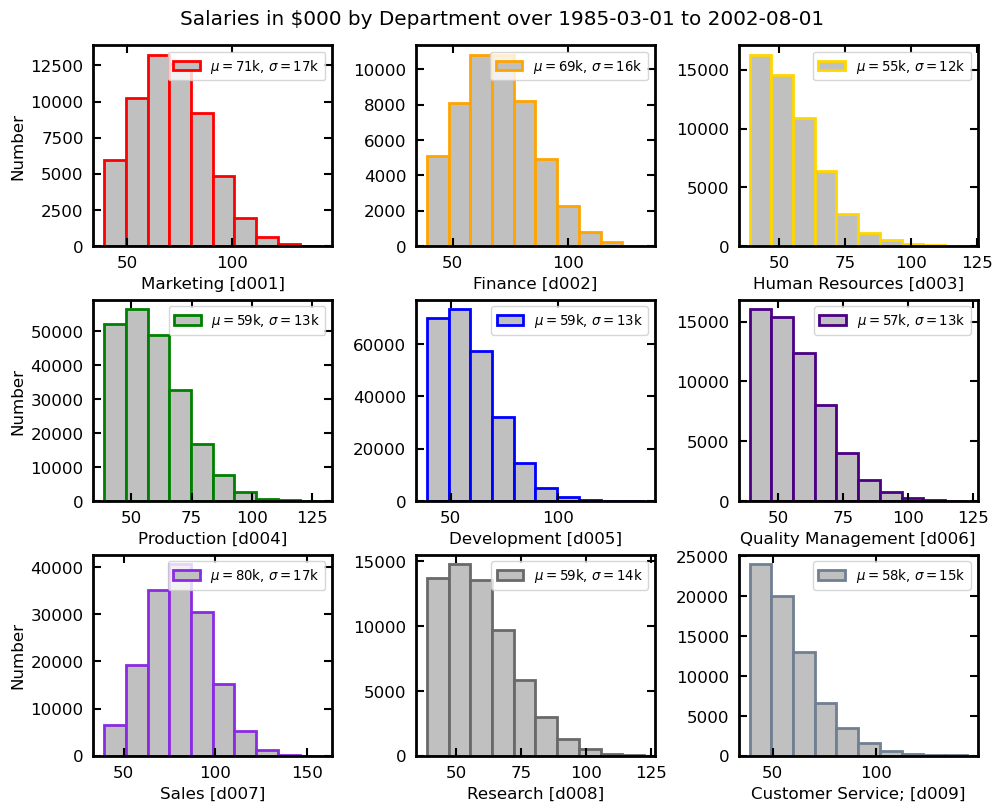

In [339]:
cur = str(input('All employees or only those still employed with us [a/s]: '))
if cur.lower() == 'a':
        sal_fixed = sal.copy()
else:
    sal_fixed = sal[sal['to_date'] < '9999-01-01']

tmp = JOIN(emp,sal_fixed,'emp_no','left')
tmp1 = JOIN(tmp,dept_emp,'emp_no','left')
tmp = tmp1.dropna(subset = ['salary'])
tmp1 = JOIN(tmp,dep,'dept_no','left')
tmp1 = tmp1[['emp_no','first_name','last_name','salary','dept_no','dept_name','from_date_x','to_date_x']]

#------------ DATE FILTER ---------------#
d1 = min(tmp1['to_date_x']); d2 = max(tmp1['to_date_x']); print(d1,d2)
dates = input('Dates range from %s to %s, select date range [y/n]: ' %(d1,d2))
if dates.lower() == 'y':
    date1 = input('date1 [in the same format as above]: ')
    date2 = input('date2: ')
else:
    date1 = d1; date2 = d2

print("\n=====================Over %s to %s =====================\n" %(date1,date2))
fil = SELECT_BETWEEN(tmp1,'to_date_x',date1,date2,'y')
#--------- DEPT NAMES ---------#
dno = []
depts = np.sort(fil['dept_no'].unique())
for i in range (0,len(depts)): 
    data = fil[fil['dept_no'] == depts[i]]
    dno.append(depts[i]); dno.append(len(data))
dno = np.reshape(dno,(-1,2)); 
dept_df = pd.DataFrame(dno, columns=['dept_no','No. staff'])
#------ QUERIES USING ABOVE FUNCTIONS ------#
tmp = GROUP_AGG(fil,'dept_no','salary','min')
tmp = tmp.rename(columns={'salary': 'Min salary'})

tmp2 = GROUP_AGG(fil,'dept_no','salary','mean'); 
tmp2 = tmp2.rename(columns={'salary': 'Ave salary'});
tmp2['Ave salary'] = round(tmp2['Ave salary'],0)
tmp['Ave salary'] = tmp2['Ave salary'] 

tmp3 = GROUP_AGG(fil,'dept_no','salary','max');
tmp3 = tmp3.rename(columns={'salary':'Max salary'})

tmp4 = JOIN(tmp,tmp3,'dept_no', 'left')
tmp5 = JOIN(tmp4,dep,'dept_no', 'left')
out = JOIN(tmp5,dept_df,'dept_no','inner')
out = out[['dept_no','dept_name', 'No. staff','Min salary', 'Ave salary','Max salary']]
print(out)

def plot_histos(bins):  # OPTIONAL HISTOGRAMS - MORE DIRECT (python) METHOD THAN ABOVE FOR GETTING STATS
    import matplotlib.pyplot as plt
    
    font = 12
    plt.rcParams.update({'font.size': font})
    colors = ['r','orange','gold','g','b','indigo','blueviolet','dimgrey','slategrey']   
    depts = out['dept_no'].unique()
    names = out['dept_name'].unique()
    #print(fil); print(depts); print(names)
    
    cols=3;rows=3
    axes = [x.replace("d00", "ax") for x in depts]
    fig, axs = plt.subplots(rows,cols, figsize=(10, 8))
    axno = dict(zip(axes, axs.flatten()))# Flatten the 3x3 array into a 1D list and zip it 

    fig.suptitle('Salaries in $000 by Department over %s to %s' %(date1,date2), y=1.0)
    
    for d in range (0,len(depts)):
        ax = axes[d]; dept = depts[d]; name = names[d]
        plt.setp(axno[ax].spines.values(),linewidth=2)
        axno[ax].tick_params(direction='in', pad = 7,length=6, width=1.5, which='major',right=True,top=True)
        axno[ax].tick_params(direction='in', pad = 7,length=3, width=1.5, which='minor',right=True,top=True)
        
        data = fil[fil['dept_no'] == dept]
        mean = 1e-3*np.mean(data['salary']); std = 1e-3*np.std(data['salary'],ddof=1)
        
        label = r"$\mu = %1.0f$k, $\sigma=%1.0f$k" %(mean,std)
        axno[ax].hist(1e-3*data['salary'], bins = bins, color="silver", ec=colors[d],lw=2, label = label)
        axno[ax].set_xlabel('%s [%s]' %(name,dept))
        if d%cols == 0:
            axno[ax].set_ylabel('Number')
        axno[ax].legend(fontsize = 0.8*font,loc='upper right')
            
    plt.tight_layout(pad=0.5)
    plt.savefig('dept_salaries.png')
    
hist = str(input('Show histograms of salary distributions for each department [y/n]: ')) 
if hist.lower() == 'y':
    plot_histos(bins=10) 

[Back to contents](#cont)

### Summary

This notebook demonstrates how SQL-style queries can be implemented in pandas to support flexible, real-world data analysis.  
The combination of query logic and Python-based workflows enables both structured analysis and deeper exploration.
